In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn tensorflow

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Random seed
np.random.seed(42)
tf.random.set_seed(42)

In [5]:
df = pd.read_csv("german_credit_data.csv")   
df.head()

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad


In [6]:
df.shape

(1000, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status_account           1000 non-null   object
 1   month_duration           1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   status_savings           1000 non-null   object
 6   years_employment         1000 non-null   object
 7   payment_to_income_ratio  1000 non-null   int64 
 8   status_and_sex           1000 non-null   object
 9   secondary_obligor        1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  collateral               1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [8]:
df.isnull().sum()

status_account             0
month_duration             0
credit_history             0
purpose                    0
credit_amount              0
status_savings             0
years_employment           0
payment_to_income_ratio    0
status_and_sex             0
secondary_obligor          0
residence_since            0
collateral                 0
age                        0
other_installment_plans    0
housing                    0
n_credits                  0
job                        0
n_guarantors               0
telephone                  0
is_foreign_worker          0
target                     0
dtype: int64

In [10]:
df["target"].unique()

array(['good', 'bad'], dtype=object)

In [11]:
df["target"] = df["target"].map({"good":1, "bad":0})

In [12]:
df["target"].unique()

array([1, 0])

In [13]:
df = pd.get_dummies(df, drop_first=True)

In [14]:
df.head()


,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors,target,status_account_< 0 DM,status_account_>= 200 DM,...,collateral_savings agreement/life insurance,other_installment_plans_none,other_installment_plans_stores,housing_own,housing_rent,job_skilled employee/ official,job_unemployed/ unskilled - non-resident,job_unskilled - resident,"telephone_yes, registered under the customers name",is_foreign_worker_yes
0,6,1169,4,4,67,2,1,1,True,False,...,False,True,False,True,False,True,False,False,True,True
1,48,5951,2,2,22,1,1,0,False,False,...,False,True,False,True,False,True,False,False,False,True
2,12,2096,2,3,49,1,2,1,False,False,...,False,True,False,True,False,False,False,True,False,True
3,42,7882,2,4,45,1,2,1,True,False,...,False,True,False,False,False,True,False,False,False,True
4,24,4870,3,4,53,2,2,0,True,False,...,True,True,False,False,False,True,False,False,False,True


In [15]:
df.shape

(1000, 49)

In [16]:
X = df.drop("target", axis=1)
y = df["target"]

In [17]:
X.shape

(1000, 48)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

X[:5]

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [21]:
X_train.shape

(800, 48)

In [22]:
X_test.shape

(200, 48)

MLP Model Define

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()

# Proper Input Layer
model.add(Input(shape=(X_train.shape[1],)))

# Hidden Layer 1
model.add(Dense(64, activation='relu'))

# Hidden Layer 2
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

In [25]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [26]:
#training
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.4859 - loss: 0.7607 - val_accuracy: 0.6875 - val_loss: 0.6188
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7031 - loss: 0.5883 - val_accuracy: 0.7000 - val_loss: 0.5725
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7453 - loss: 0.5338 - val_accuracy: 0.6938 - val_loss: 0.5449
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7750 - loss: 0.4917 - val_accuracy: 0.7375 - val_loss: 0.5257
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7891 - loss: 0.4583 - val_accuracy: 0.7312 - val_loss: 0.5156
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8047 - loss: 0.4314 - val_accuracy: 0.7375 - val_loss: 0.5126
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8125 - loss: 0.4093 - val_accuracy: 0.7437 - val_loss: 0.5135
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8188 - loss: 0.3902 - val_accuracy: 0.7437 - v

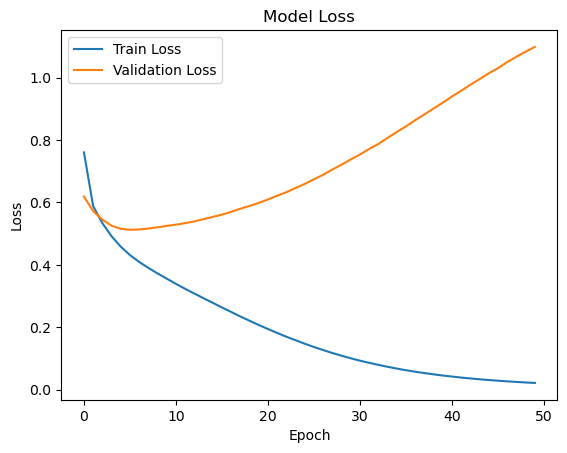

In [27]:
#loss graph plot 

import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

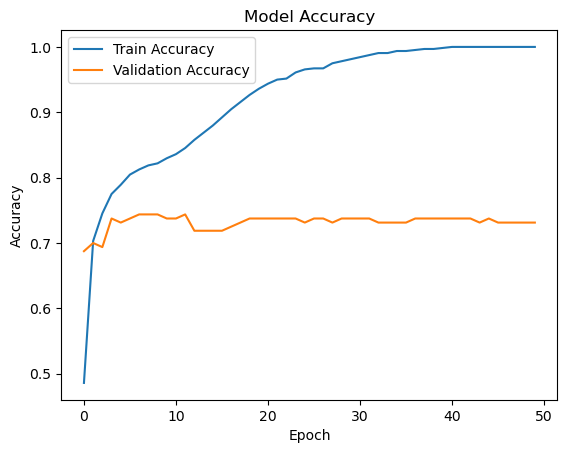

In [28]:
#accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()

In [29]:
#Test Data Evaluation
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7250 - loss: 1.0750 
Test Accuracy: 0.7250000238418579


In [31]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


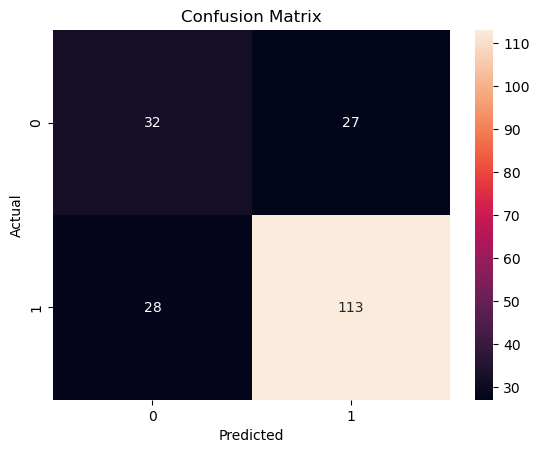

In [32]:
#confusion matrix 
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.53      0.54      0.54        59
           1       0.81      0.80      0.80       141

    accuracy                           0.72       200
   macro avg       0.67      0.67      0.67       200
weighted avg       0.73      0.72      0.73       200

